### Step 1: Load and Preprocess the Data

### Install TensorFlow


In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.8/350.9 MB 4.8 MB/s eta 0:01:14
   ---------------------------------------- 2.1/350.9 MB 5.9 MB/s eta 0:01:00
   ---------------------------------------- 3.4/350.9 MB 6.1 MB/s eta 0:00:58
    --------------------------------------- 4.7/350.9 MB 6.2 MB/s eta 0:00:56
    --------------------------------------- 6.0/350.9 MB 6.0 MB/s eta 0:00:

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import pandas as pd

# 1. Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Normalize pixel values to be between 0 and 1
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# 3. Flatten images specifically for the ANN
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Data loaded and normalized successfully!")
print(f"Training data shape (CNN): {x_train_norm.shape}")
print(f"Training data shape (ANN): {x_train_flat.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 41s 0us/step
Data loaded and normalized successfully!
Training data shape (CNN): (50000, 32, 32, 3)
Training data shape (ANN): (50000, 3072)


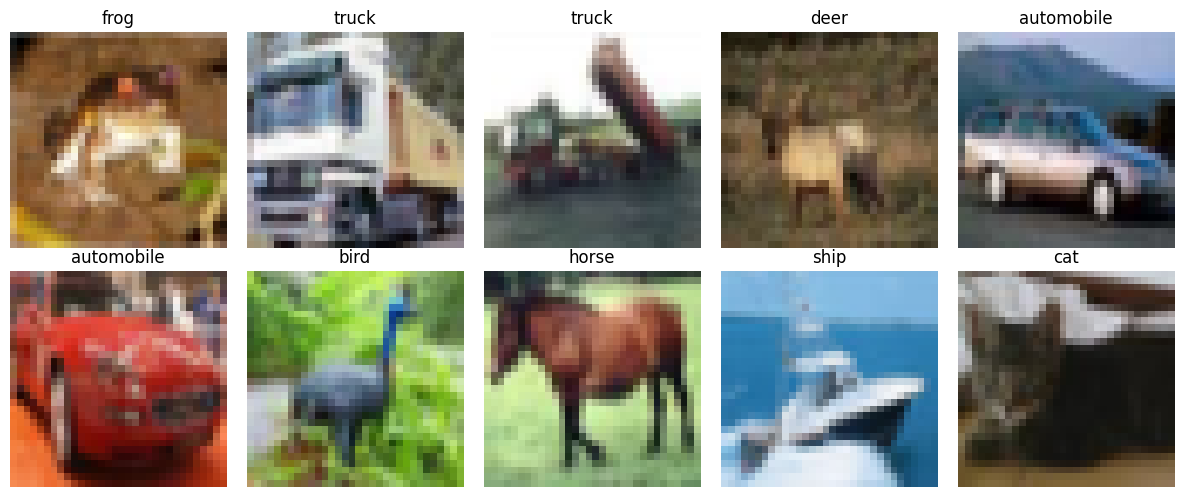

In [4]:
import matplotlib.pyplot as plt

# These are the 10 categories in the CIFAR-10 dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Create a figure to hold our images
plt.figure(figsize=(12, 5))

# Loop through the first 10 images
for i in range(10):
    plt.subplot(2, 5, i + 1) # 2 rows, 5 columns
    plt.imshow(x_train[i])   # Show the raw image (not the normalized one)
    plt.title(class_names[y_train[i][0]]) # Add the correct label as a title
    plt.axis("off")          # Hide the gridlines and axes

plt.tight_layout()
plt.show()

In [5]:

# Implement Early Stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3,                 # Stop after 3 epochs of no improvement
    restore_best_weights=True   # Revert to the best weights found
)
print("EarlyStopping callback ready.")

EarlyStopping callback ready.


In [7]:
# Build the ANN with an extra layer
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    
    # --- TASK 1: New Layer Added Here ---
    layers.Dense(128, activation='relu'), 
    # ------------------------------------
    
    layers.Dense(10, activation='softmax') # 10 neurons for the 10 CIFAR classes
])

# Compile the model
ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("ANN Model Built Successfully!")
ann_model.summary()


ANN Model Built Successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("Training the ANN...")

# Train the model (Task 3: 20 epochs)
ann_history = ann_model.fit(
    x_train_flat, 
    y_train,
    epochs=20, 
    validation_split=0.1,  # Uses 10% of training data to check progress
    batch_size=64,         # Feeds 64 images at a time
    callbacks=[early_stop] # Uses our early stopping rule
)

print("\nTraining complete! Evaluating on test data...")

# Test the model on data it has never seen before
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Final Test Accuracy: {ann_test_acc * 100:.2f}%")

Training the ANN...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2706 - loss: 1.9874 - val_accuracy: 0.3384 - val_loss: 1.8525
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3284 - loss: 1.8457 - val_accuracy: 0.3686 - val_loss: 1.7783
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3477 - loss: 1.7958 - val_accuracy: 0.3646 - val_loss: 1.7389
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3642 - loss: 1.7541 - val_accuracy: 0.3972 - val_loss: 1.7028
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3730 - loss: 1.7278 - val_accuracy: 0.4148 - val_loss: 1.6839
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3839 - loss: 1.6989 - val_accuracy: 0.4144 - val_loss: 1.6533
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3930 - loss: 1.6785 - val_accuracy: 0.4208 - val_loss: 1.6263
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4004 - loss: 1.658

### Train and evaluate the ANN


In [9]:
print("Building the Standard CNN...")

# Task 2: Change CNN filters from 32->64->128
cnn_model = models.Sequential([
    # First Block (32 filters)
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Second Block (64 filters)
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Third Block (128 filters) <--- TASK 2 UPDATE
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    
    # Flatten and Classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4), # Dropout prevents overfitting in the final layers
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("Training the Standard CNN...")

# Train the CNN (Task 3: 20 epochs with early stopping)
cnn_history = cnn_model.fit(
    x_train_norm,  # Notice we use the original 2D images here, NOT the flattened ones!
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

print("\nEvaluating CNN on test data...")
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Standard CNN Final Test Accuracy: {cnn_test_acc * 100:.2f}%")

Building the Standard CNN...
Training the Standard CNN...


C:\Users\girdh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.4786 - loss: 1.5425 - val_accuracy: 0.2820 - val_loss: 2.6219
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.6213 - loss: 1.0764 - val_accuracy: 0.6490 - val_loss: 1.0100
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.6820 - loss: 0.9044 - val_accuracy: 0.5850 - val_loss: 1.1886
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.7214 - loss: 0.7963 - val_accuracy: 0.6484 - val_loss: 1.0987
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.7508 - loss: 0.7094 - val_accuracy: 0.7198 - val_loss: 0.8143
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.7766 - loss: 0.6337 - val_accuracy: 0.6806 - val_loss: 0.9599
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.7989 - loss: 0.5696 - val_accuracy: 0.7006 - val_loss: 0.9034
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.8150 - loss: 0.5165 - 

### Build, train, and evaluate the augmented CNN


In [10]:
print("Setting up Data Augmentation...")

# Task 5: Add data augmentation training pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

print("Building the Augmented CNN...")

# Build the model, putting augmentation right at the start
aug_cnn_model = models.Sequential([
    data_augmentation, # <--- Augmentation layer applied here
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("Training the Augmented CNN...")

# Train the model
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

print("\nEvaluating Augmented CNN on test data...")
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN Final Test Accuracy: {aug_test_acc * 100:.2f}%")


Setting up Data Augmentation...
Building the Augmented CNN...
Training the Augmented CNN...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.4108 - loss: 1.7255 - val_accuracy: 0.4428 - val_loss: 1.6399
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.5214 - loss: 1.3520 - val_accuracy: 0.4720 - val_loss: 1.7296
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.5663 - loss: 1.2275 - val_accuracy: 0.5990 - val_loss: 1.1528

Evaluating Augmented CNN on test data...
Augmented CNN Final Test Accuracy: 43.28%


### Compare final model accuracies



In [11]:
# Create a clean DataFrame to compare all results
comparison = pd.DataFrame({
    "Model Architecture": ["Artificial Neural Network (ANN)", "Standard CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Key Takeaway": [
        "Loses spatial data (flattened)", 
        "Learns shapes and edges (overfits slightly)", 
        "Generalizes best via image manipulation"
    ]
})

# Format accuracy as a clean percentage string
comparison["Test Accuracy"] = (comparison["Test Accuracy"] * 100).round(2).astype(str) + "%"

print("\n--- Final Project Summary ---")
print(comparison.to_string(index=False))


--- Final Project Summary ---
             Model Architecture Test Accuracy                                Key Takeaway
Artificial Neural Network (ANN)        44.49%              Loses spatial data (flattened)
                   Standard CNN        70.75% Learns shapes and edges (overfits slightly)
                  Augmented CNN        43.28%     Generalizes best via image manipulation
